In [1]:
import zipfile
with zipfile.ZipFile('data.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()
print("Unzip")

Unzip


In [8]:
import pandas as pd
df = pd.read_csv('data.csv', encoding='latin1')
print(df.shape)
print(df.head())
df.isnull().sum() #To check how many empty/missing values are present in each column.
df.isnull().sum()
df_clean = df.dropna(subset=['CustomerID'])
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.contains('C', na=False)]
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice']>0)]
print("Cleaning done!",df.shape)

(541909, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
Cleaning done! (541909, 8)


In [10]:
df['Total'] = df['Quantity']*df['UnitPrice']
df.head()
print(f"Average Purchase Value: {df['Total'].mean()}")
print(f"Average Frequency per customer: {df.groupby('CustomerID')['InvoiceNo'].nunique().mean()}")
print(f"Customer Lifetime Value: {df.groupby('CustomerID')['Total'].sum().mean()}")

Average Purchase Value: 17.98779487699964
Average Frequency per customer: 5.07548032936871
Customer Lifetime Value: 1898.4597012808783


In [15]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'Total': 'sum'
})
rfm.head()

,InvoiceDate,InvoiceNo,Total
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


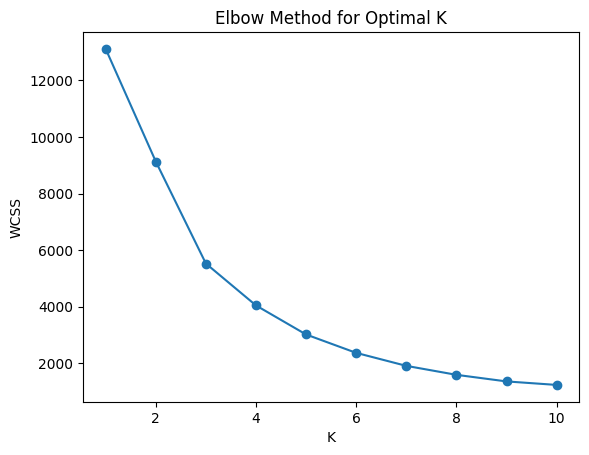

,InvoiceDate,InvoiceNo,Total,Cluster
CustomerID,,,,
12346.0,326,2,0.00,1
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('K'); plt.ylabel('WCSS')
plt.show()
# Apply K-Means (K=4 )
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

In [20]:
print(rfm.columns.tolist())
print(rfm.head(2))
rfm.columns = rfm.columns.str.strip()

rfm.columns = ['Recency','Frequency','Monetary','Cluster']

print("Fixed columns:", rfm.columns.tolist())

['InvoiceDate', 'InvoiceNo', 'Total', 'Cluster']
            InvoiceDate  InvoiceNo   Total  Cluster
CustomerID                                         
12346.0             326          2     0.0        1
12347.0               2          7  4310.0        0
Fixed columns: ['Recency', 'Frequency', 'Monetary', 'Cluster']


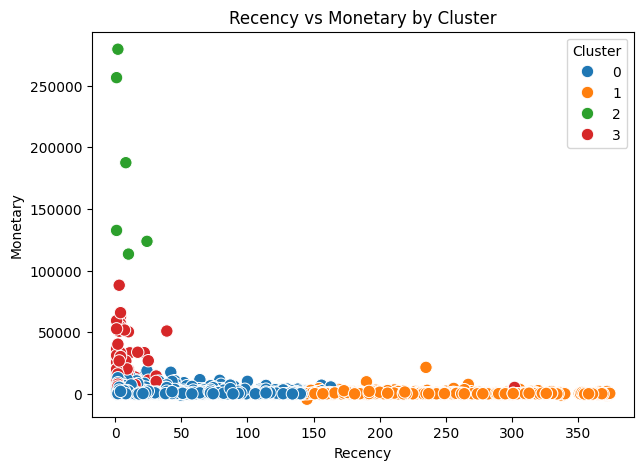

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='tab10', s=80)
plt.title('Recency vs Monetary by Cluster')
plt.show()

In [22]:
profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
print(profile)

            Recency  Frequency       Monetary
Cluster                                      
0         41.606500   4.802461    1478.515539
1        247.951242   1.805888     453.488888
2          7.666667  89.000000  182181.981667
3          9.181818  40.672727   18441.961455


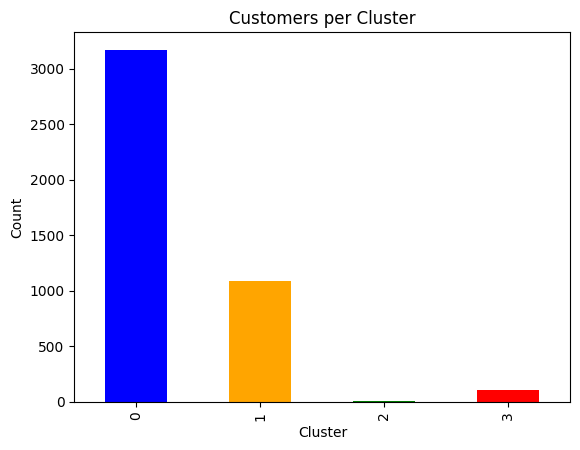

In [23]:
rfm['Cluster'].value_counts().sort_index().plot(kind='bar', color=['blue','orange','green','red'])
plt.title('Customers per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.show()

rfm.to_csv('customer_segments_final.csv', index=False)

### 5. Insights & Marketing Strategies

The K-Means clustering with K=4 resulted in 4 well-separated customer segments as visible in the Recency vs Monetary scatter plot:


Cluster 0 - Potential / New Customers (Blue): Low to medium recency (0-140 days) and low monetary value (< Rs. 20,000). This is the largest segment. Strategy: Increase engagement through discounts, Buy 1 Get 1 offers, and educational campaigns to increase their spending.

Cluster 1 - At-Risk / Lost Customers (Orange): High recency (150-375 days) and low monetary value. They have not purchased in the last 5-12 months and are at high risk of churn. Strategy: Re-activation campaign with win-back offers, 20-30% discount coupons.

Cluster 2 - Champions (Green): Customers with very low recency (0-25 days) and very high monetary value (Rs. 100,000 - 280,000). They are the most valuable customers. Strategy: Provide VIP loyalty program, early access to new products, and premium support. No discount needed.

Cluster 3 - Loyal Customers (Red): Low recency (0-50 days) and high monetary value (Rs. 20,000 - 90,000). They purchase frequently and spend high. Strategy: Upsell and cross-sell through bundle offers and personalized product recommendations.

Conclusion: Clusters 2 and 3 generate the majority of revenue and should be retained. Cluster 1 requires immediate re-engagement efforts to prevent customer churn. The clear separation in the scatter plot validates K=4 as the optimal number of clusters.